# Extreme Weather Prototype (All Data Are Synthetic)

> **Purpose:** This notebook is a *prototype* that demonstrates the full workflow we will use in our final project on **three types of extreme weather**: a **tornado outbreak**, a **heatwave**, and a **lake‑effect snow** event.  
> The figures below use **synthetic placeholders** so we can finalize structure, narration, and plotting. In the final project we will replace the synthetic arrays with **ERA5 reanalysis**, **GFS model outputs**, **satellite imagery**, and **surface station observations**.

The prototype contains four parts:

1. **Tornado Outbreak Overview (Synthetic)** — track-style animation-ready setup and a single-frame static preview.  
2. **Heatwave Overview (Synthetic)** — time series of near-surface temperature with a simple model-versus-reference comparison.  
3. **Lake-Effect Snow Overview (Synthetic)** — synthetic radar reflectivity loop (and single-frame preview).  
4. **Model Skill Verification (Synthetic)** — error growth with lead time across latitude bands and variables.


## Abstract

This project examines three types of extreme weather events—**tornado outbreaks**, **heatwaves**, and **lake‑effect snowstorms**—to better understand their development and how accurately models can predict them. Using common workflows that will later be driven by **ERA5 reanalysis**, **GFS forecasts**, **satellite imagery**, and **surface/station observations**, we analyze how each event evolves and evaluate model performance for key variables (temperature, wind, and precipitation) across different time and spatial scales. By comparing results across these events, we identify strengths and weaknesses in current forecasting systems and outline improvements for future prediction of extreme weather.

*Prototype note:* All figures below are generated from synthetic data to lock down the analysis flow and visual design before swapping in real datasets.


## Introduction

Extreme weather events such as **tornado outbreaks**, **heatwaves**, and **lake‑effect snow** represent major challenges in meteorological forecasting and climate analysis. Although these phenomena involve unique mesoscale and synoptic processes, they can be examined with similar datasets and verification frameworks. This notebook provides a unified, modular workflow:
- **Event overviews** with simple, event‑specific visualizations (track, time series, radar frames).
- **Model verification** that quantifies forecast error growth with lead time, aggregated by latitude bands and by variable.

In this prototype we use randomly generated arrays that mimic plausible signals. In the final project we will replace them with real inputs (ERA5/GFS/observations) while keeping the exact same code structure.


## Dependencies

In [1]:
# Standard scientific stack (matplotlib only; one chart per figure; no custom colors)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Reproducibility
np.random.seed(42)


## 1. Tornado Outbreak Overview (Synthetic)

We simulate a single long‑track tornado moving northeast with small random meanders and an intensity proxy. The code produces:

- A **static track preview** (always available).
- An optional **animation** (commented `.save`) you can export as MP4/GIF when ffmpeg/imagemagick is present.


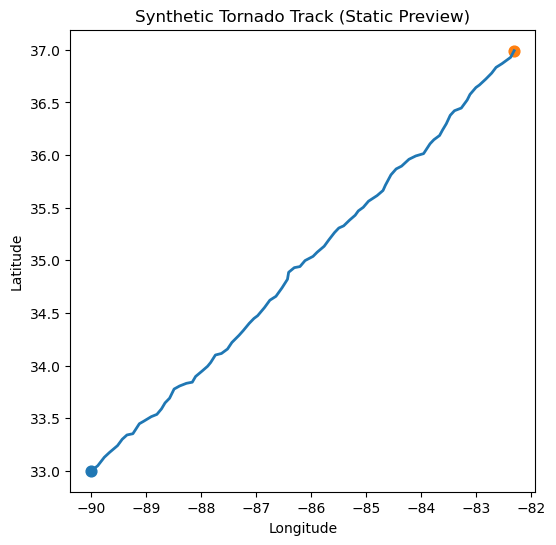

In [2]:
# Synthetic tornado track and intensity
n = 80
lon0, lat0 = -90.0, 33.0
mean_step = np.array([0.1, 0.05])   # lon, lat step per frame
noise = np.random.normal(scale=[0.03, 0.02], size=(n, 2))

steps = mean_step + noise
track = np.cumsum(np.vstack([np.array([lon0, lat0]), steps]), axis=0)
lons, lats = track[:,0], track[:,1]

# Synthetic intensity (e.g., wind proxy) with a bell shape
t = np.linspace(0, 1, n)
intensity = 0.2 + 0.8*np.exp(-((t-0.5)/0.2)**2) + 0.05*np.random.randn(n)

# ---- Static preview ----
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(lons, lats, linewidth=2)
ax.scatter(lons[0], lats[0], s=60)              # start
ax.scatter(lons[-1], lats[-1], s=60)            # end
ax.set_title('Synthetic Tornado Track (Static Preview)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.show()


## 2. Heatwave Overview (Synthetic)

We create a **15‑day heatwave** time series with a sinusoidal warming signal and random noise. We also generate a synthetic "model" and compute a simple error metric for verification.


In [3]:
t = np.linspace(0, 1, 60)
lons = -90 + 8*t
lats =  33 + 4*np.sin(2*np.pi*t)

assert len(lons)>1 and len(lons)==len(lats)
assert not (np.isnan(lons).any() or np.isnan(lats).any())

fig, ax = plt.subplots(figsize=(6,6))
ln, = ax.plot([], [], lw=2)
dot = ax.scatter([], [], s=80)

pad = 0.5
ax.set_xlim(lons.min()-pad, lons.max()+pad)
ax.set_ylim(lats.min()-pad, lats.max()+pad)
ax.set_title('Synthetic Tornado Track (Animation)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

def init():
    ln.set_data([], [])
    dot.set_offsets(np.c_[lons[0], lats[0]])
    return ln, dot

def update(i):
    ln.set_data(lons[:i+1], lats[:i+1])
    dot.set_offsets(np.c_[lons[i], lats[i]])
    return ln, dot

anim = animation.FuncAnimation(fig, update, init_func=init,
                               frames=len(lons), interval=120, blit=False)

html = anim.to_jshtml()
plt.close(fig)           
display(HTML(html)) 

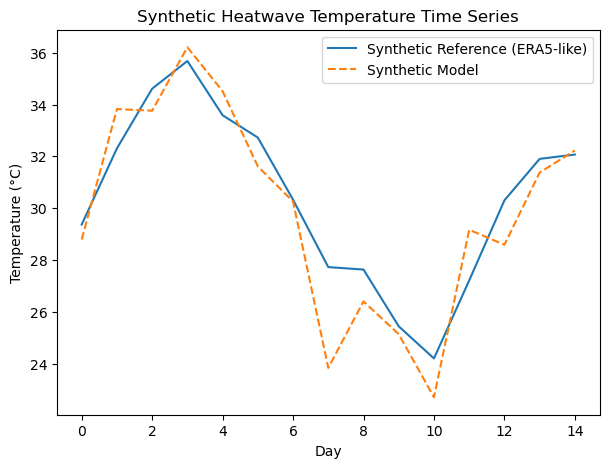

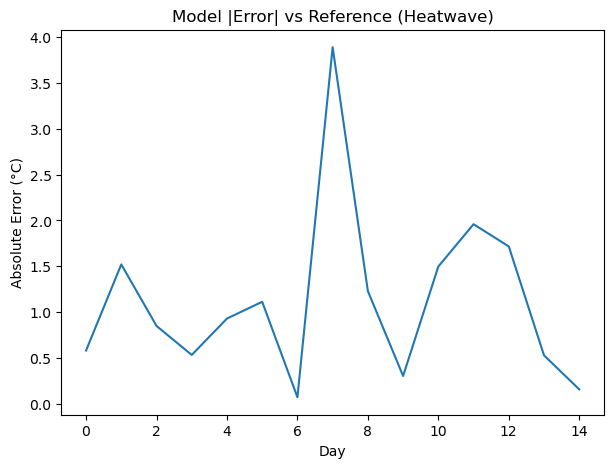

In [4]:
# Synthetic heatwave time series
days = np.arange(0, 15)
truth_temp = 30 + 5*np.sin(days/2) + np.random.normal(0, 0.8, len(days))  # reference
model_temp = truth_temp + np.random.normal(0, 1.2, len(days))             # model

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(days, truth_temp, label='Synthetic Reference (ERA5-like)')
ax.plot(days, model_temp, linestyle='--', label='Synthetic Model')
ax.set_title('Synthetic Heatwave Temperature Time Series')
ax.set_xlabel('Day'); ax.set_ylabel('Temperature (°C)'); ax.legend()
plt.show()

# Simple error time series
abs_error = np.abs(model_temp - truth_temp)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(days, abs_error)
ax.set_title('Model |Error| vs Reference (Heatwave)')
ax.set_xlabel('Day'); ax.set_ylabel('Absolute Error (°C)')
plt.show()


## 3. Lake-Effect Snow Overview (Synthetic Radar)

We mimic a radar reflectivity loop as a sequence of random 2‑D arrays with evolving patterns. The notebook shows a single frame and also constructs an animation object you can export if desired.


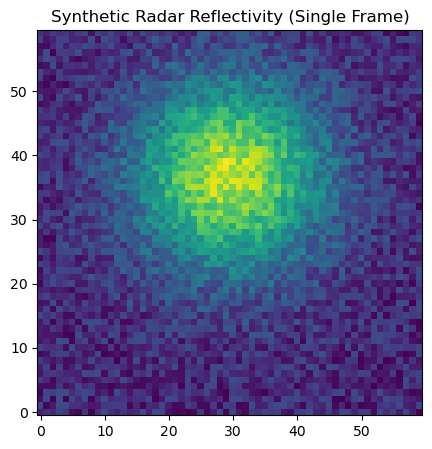

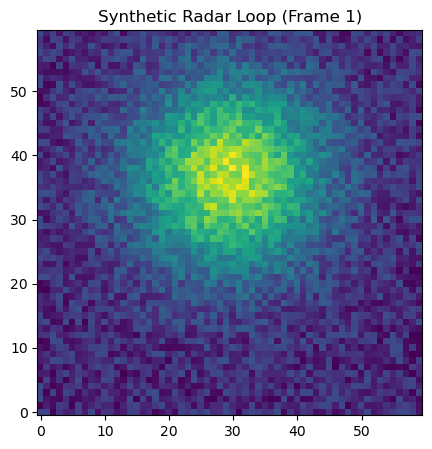

In [5]:
# Synthetic radar frames
nx, ny = 60, 60
frames = 12

def make_frame(k):
    # drifting Gaussian blobs
    x = np.linspace(-2, 2, nx)
    y = np.linspace(-2, 2, ny)
    X, Y = np.meshgrid(x, y)
    cx, cy = 0.5*np.sin(2*np.pi*k/frames), 0.5*np.cos(2*np.pi*k/frames)
    Z = np.exp(-((X-cx)**2 + (Y-cy)**2)) + 0.3*np.random.rand(ny, nx)
    return Z

# Single-frame preview
Z0 = make_frame(0)
fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(Z0, origin='lower')
ax.set_title('Synthetic Radar Reflectivity (Single Frame)')
plt.show()

# Optional animation
fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(make_frame(0), origin='lower')
ax.set_title('Synthetic Radar Loop')

def update_frame(i):
    im.set_data(make_frame(i))
    ax.set_title(f'Synthetic Radar Loop (Frame {i+1})')
    return [im]

radar_anim = animation.FuncAnimation(fig, update_frame, frames=frames, interval=200, blit=True)
plt.show()

## 4. Model Skill Verification (Synthetic)

We emulate forecast error growth with lead time and summarize results across:
- **Latitude bands:** lower vs mid latitude.
- **Variables:** temperature, precipitation, wind.

The arrays are synthetic but shaped to produce realistic‑looking curves.


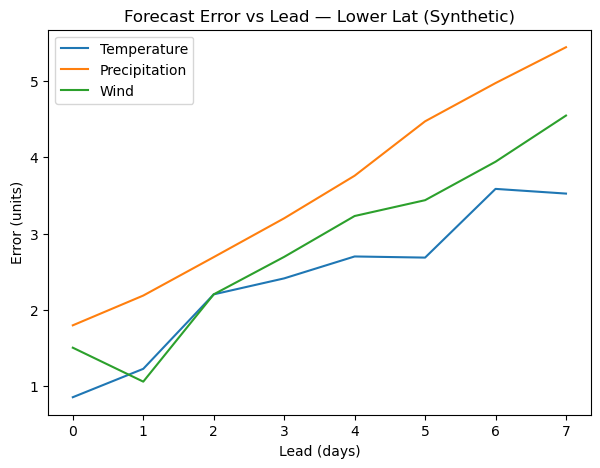

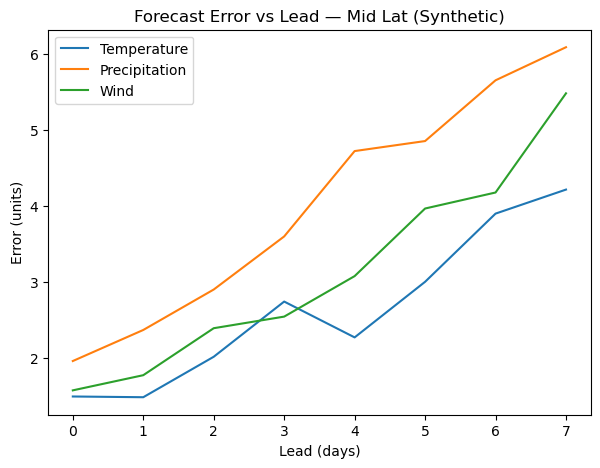

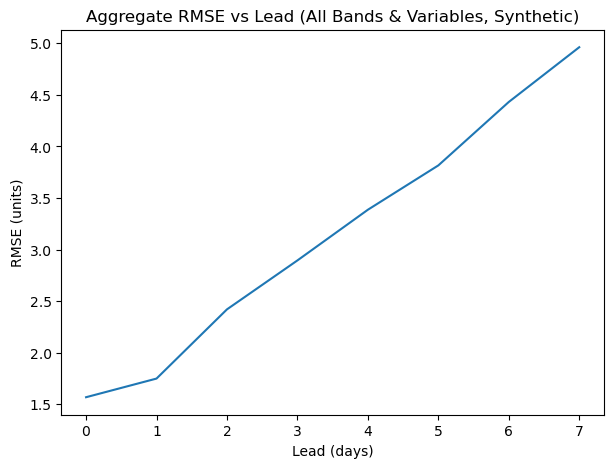

In [6]:
# ---- Synthetic verification arrays ----
leads = np.arange(0, 8)  # 0–7 day lead
lat_bands = ['Lower Lat', 'Mid Lat']
variables = ['Temperature', 'Precipitation', 'Wind']

# Base errors for each variable
base = {'Temperature': 1.0, 'Precipitation': 1.6, 'Wind': 1.2}
growth = {'Temperature': 0.35, 'Precipitation': 0.55, 'Wind': 0.45}

errors = {}
for band in lat_bands:
    band_err = {}
    for var in variables:
        # error grows with lead plus noise; mid‑lat a touch higher
        band_factor = 1.0 if band == 'Lower Lat' else 1.15
        e = base[var] + growth[var]*leads + 0.2*np.random.randn(len(leads))
        band_err[var] = band_factor * np.abs(e)
    errors[band] = band_err

# ---- Plot by latitude band ----
for band in lat_bands:
    fig, ax = plt.subplots(figsize=(7,5))
    for var in variables:
        ax.plot(leads, errors[band][var], label=var)
    ax.set_title(f'Forecast Error vs Lead — {band} (Synthetic)')
    ax.set_xlabel('Lead (days)'); ax.set_ylabel('Error (units)'); ax.legend()
    plt.show()

# ---- Aggregate RMSE across variables by lead ----
rmse = np.sqrt(np.mean(
    [np.array(list(errors[band].values()))**2 for band in lat_bands], axis=(0,1)
))

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(leads, rmse)
ax.set_title('Aggregate RMSE vs Lead (All Bands & Variables, Synthetic)')
ax.set_xlabel('Lead (days)'); ax.set_ylabel('RMSE (units)')
plt.show()


## Conclusion (Prototype)

This notebook locks down the **analysis structure** for three extreme weather events and a common **verification** block, using **synthetic placeholders** so that all sections render cleanly without external data. In the final project we will:

- Swap the synthetic arrays for real inputs from **ERA5**, **GFS**, **satellite imagery**, and **surface/station observations**.  
- Preserve the same plotting and verification code so that comparisons remain reproducible.  
- Expand each event section with additional context (synoptic setup, maps, and station time series).
